# Разработка A/B-тестирования и анализ результатов

## Описание данных

Три таблицы:

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-15 по 2025-09-23. Путь к файлу: `/datasets/sessions_project_history.csv`.

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14. Путь к файлу: `/datasets/sessions_project_test_part.csv`.

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02. Путь к файлу: `/datasets/sessions_project_test.csv`.

У этих таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения.

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).


## Что нужно сделать
Задачи: рассчитать параметры теста, оценить корректность его проведения и проанализировать результаты эксперимента.

### 1. Работа с историческими данными (EDA)

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
from math import ceil
from statsmodels.stats.proportion import proportions_ztest

#### 1.1. Загрузка исторических данных

In [27]:
sessions_history = pd.read_csv('sessions_project_history.csv')

sessions_history.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


#### 1.2. Знакомство с данными
- Для каждого уникального пользователя `user_id` рассчитайте количество уникальных сессий `session_id`.

- Выведите на экран все данные из таблицы `sessions_history` для одного пользователя с наибольшим количеством сессий. Если таких пользователей несколько, выберите любого из них.

- Изучите таблицу для одного пользователя, чтобы лучше понять логику формирования каждого столбца данных.

In [28]:
sessions_per_user = sessions_history.groupby('user_id')['session_id'].nunique()
top_user_id = sessions_per_user.idxmax()
print(f"Пользователь с наибольшим количеством сессий: {top_user_id}")
print(f"Количество сессий: {sessions_per_user.max()}")
sessions_history[sessions_history['user_id'] == top_user_id]

Пользователь с наибольшим количеством сессий: 10E0DEFC1ABDBBE0
Количество сессий: 10


,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


#### 1.3. Анализ числа регистраций
Одна из важнейших метрик продукта — число зарегистрированных пользователей. Используя исторические данные, визуализируйте, как менялось число регистраций в приложении за время его существования. Пользователь считается зарегистрированным только в день совершения регистрации. Таким образом, вам необходимо проанализировать количество зарегистрированных активных пользователей за каждый день без накопления (аналог DAU, но для регистраций пользователей).

- Агрегируйте исторические данные и рассчитайте число уникальных пользователей и число зарегистрированных пользователей для каждого дня наблюдения. Для простоты считайте, что у пользователя в течение дня бывает одна сессия максимум и статус регистрации в течение одного дня не может измениться.

- Постройте линейные графики общего числа пользователей и общего числа зарегистрированных пользователей по дням. Отобразите их на одном графике.

- Постройте отдельный линейный график доли зарегистрированных пользователей от всех пользователей по дням.

- На обоих графиках должны быть заголовок, подписанные оси X и Y, сетка и легенда.

In [29]:
# Приводим дату к формату datetime
sessions_history['session_date'] = pd.to_datetime(sessions_history['session_date'])

# Агрегируем данные по дням
daily_stats = sessions_history.groupby('session_date').agg(
    total_users=('user_id', 'nunique'),
    registered_users=('registration_flag', 'sum')
).reset_index()

# Считаем долю зарегистрированных пользователей от всех пользователей за день
daily_stats['registered_share'] = daily_stats['registered_users'] / daily_stats['total_users']

daily_stats.head()

,session_date,total_users,registered_users,registered_share
0,2025-08-11,3919,169,0.043123
1,2025-08-12,6056,336,0.055482
2,2025-08-13,8489,464,0.054659
3,2025-08-14,10321,625,0.060556
4,2025-08-15,14065,840,0.059723


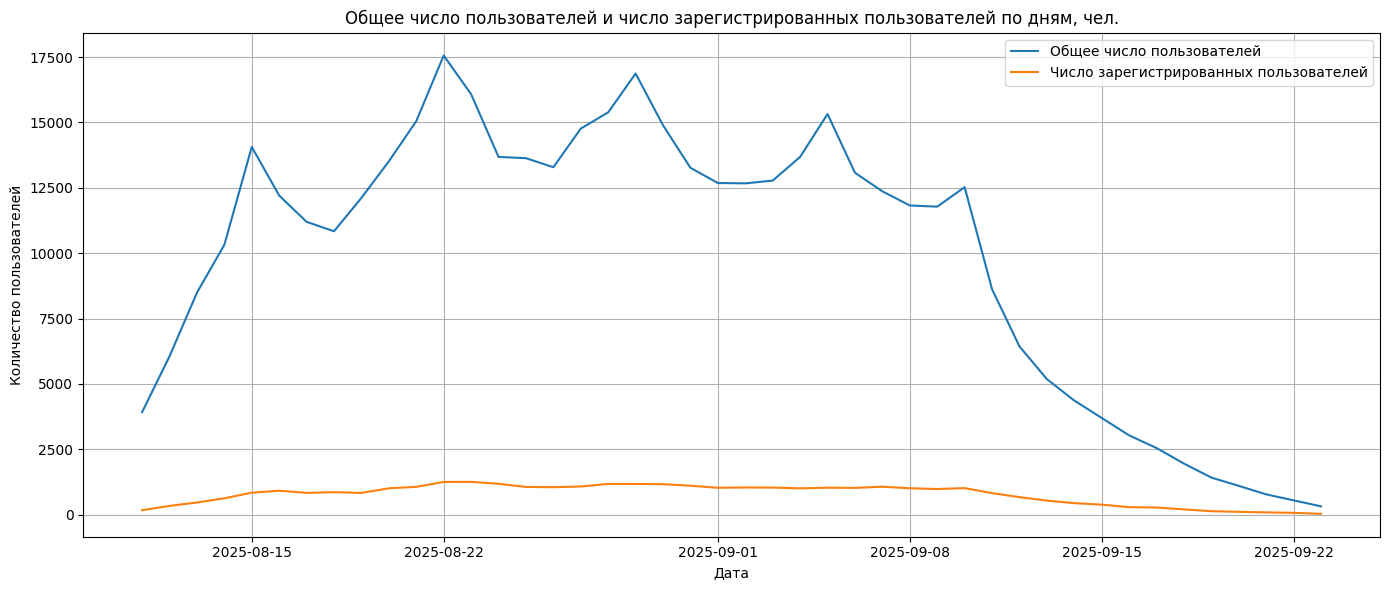

In [30]:
plt.figure(figsize=(14, 6))
plt.plot(daily_stats['session_date'], daily_stats['total_users'], label='Общее число пользователей')
plt.plot(daily_stats['session_date'], daily_stats['registered_users'], label='Число зарегистрированных пользователей')
plt.title('Общее число пользователей и число зарегистрированных пользователей по дням, чел.')
plt.xlabel('Дата')
plt.ylabel('Количество пользователей')
plt.grid(True)
plt.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

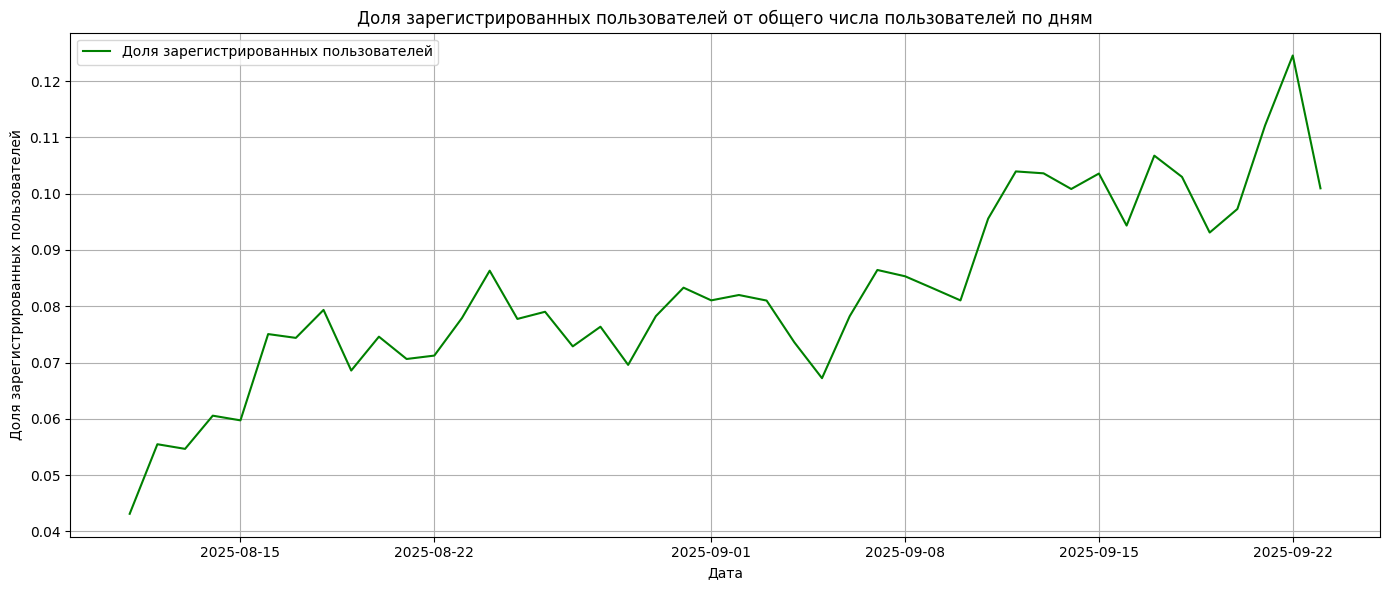

In [31]:
plt.figure(figsize=(14, 6))
plt.plot(daily_stats['session_date'], daily_stats['registered_share'], label='Доля зарегистрированных пользователей', color='green')
plt.title('Доля зарегистрированных пользователей от общего числа пользователей по дням')
plt.xlabel('Дата')
plt.ylabel('Доля зарегистрированных пользователей')
plt.grid(True)
plt.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Промежуточный вывод:**

• После 2025-09-10 резкое падение общего числа пользователей и снижается число регистраций.

• Падение общего числа пользователей позитивно сказалось на доле зарегистрированных пользователей, которая имеет тенденцию к росту. 

#### 1.4. Анализ числа просмотренных страниц
Другая важная метрика продукта — число просмотренных страниц в приложении. Чем больше страниц просмотрено, тем сильнее пользователь увлечён контентом, а значит, выше шансы, что он зарегистрируется и оплатит подписку.

В рамках задания проанализируйте число просмотренных страниц во время первых сессий пользователей. Найдите количество первых сессий для каждого значения количества просмотренных страниц. Например: одну страницу просмотрели в 8978 первых сессиях, две страницы — в 32 494 первых сессиях и так далее.

- Постройте столбчатую диаграмму, где по оси X будет число просмотренных страниц, по оси Y — количество сессий.

- На диаграмме должны быть заголовок, подписанные оси X и Y.

In [32]:
# Оставляем только первые сессии пользователей
first_sessions = sessions_history[sessions_history['session_number'] == 1]

# Считаем количество первых сессий для каждого значения числа просмотренных страниц
pages_distribution = first_sessions['page_counter'].value_counts().sort_index()

pages_distribution.head(10)

1     8978
2    32494
3    50939
4    32739
5     8075
6      777
7       37
Name: page_counter, dtype: int64

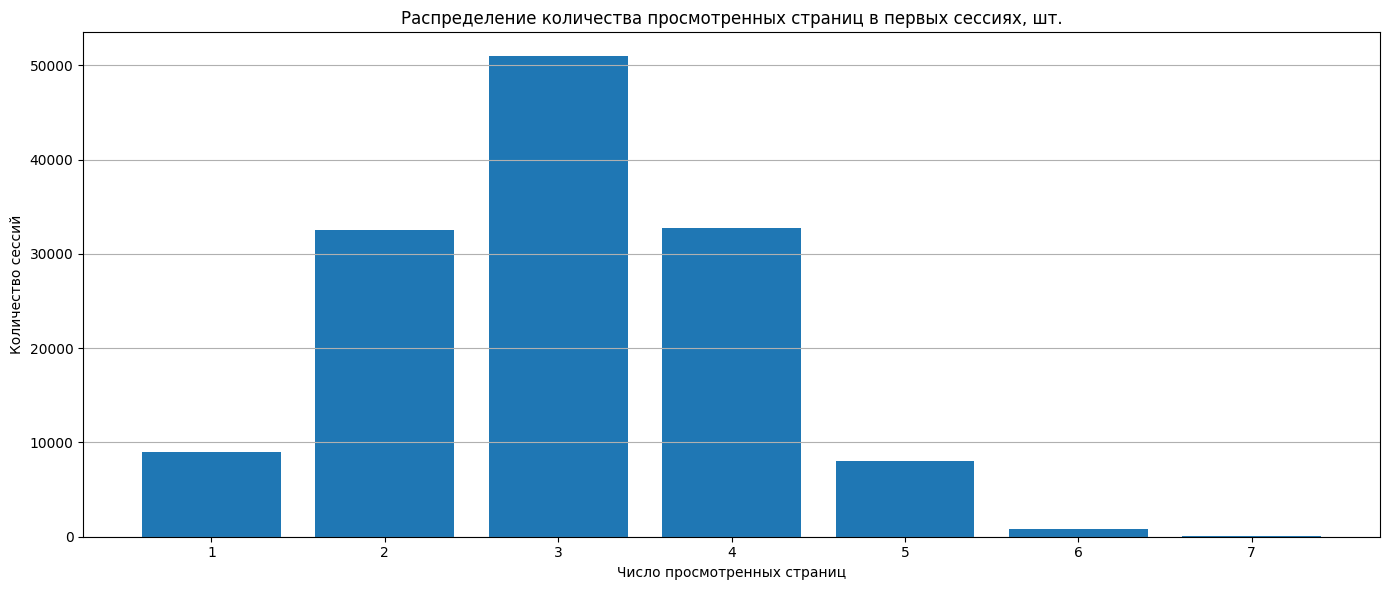

In [33]:
plt.figure(figsize=(14, 6))
plt.bar(pages_distribution.index, pages_distribution.values)
plt.title('Распределение количества просмотренных страниц в первых сессиях, шт.')
plt.xlabel('Число просмотренных страниц')
plt.ylabel('Количество сессий')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

**Промежуточный вывод:**

• В своих первых сессиях пользователи чаще всего просматривают 3 страницы (51 тыс. сессий), затем 4 и 3 страницы (по 32,5 тыс. сессий). Реже всего просматривают 6 и 7 страниц.

#### 1.5. Доля пользователей, просмотревших более четырёх страниц
Продуктовая команда продукта считает, что первые сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций. Этот показатель является важной прокси-метрикой для продукта.

- В датафрейме `sessions_history` создайте дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если было просмотрено меньше.

- Постройте график со средним значением доли успешных первых сессий от всех первых сессий пользователей. Данные нужно визуализировать по дням за весь период наблюдения.

In [34]:
sessions_history['good_session'] = (sessions_history['page_counter'] >= 4).astype(int)

sessions_history.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,good_session
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone,0
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android,1
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC,1
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android,1
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android,0


In [35]:

first_sessions = sessions_history[sessions_history['session_number'] == 1]

daily_good_share = first_sessions.groupby('session_date')['good_session'].mean().reset_index()

daily_good_share.head()

,session_date,good_session
0,2025-08-11,0.312835
1,2025-08-12,0.298344
2,2025-08-13,0.306861
3,2025-08-14,0.319098
4,2025-08-15,0.311114


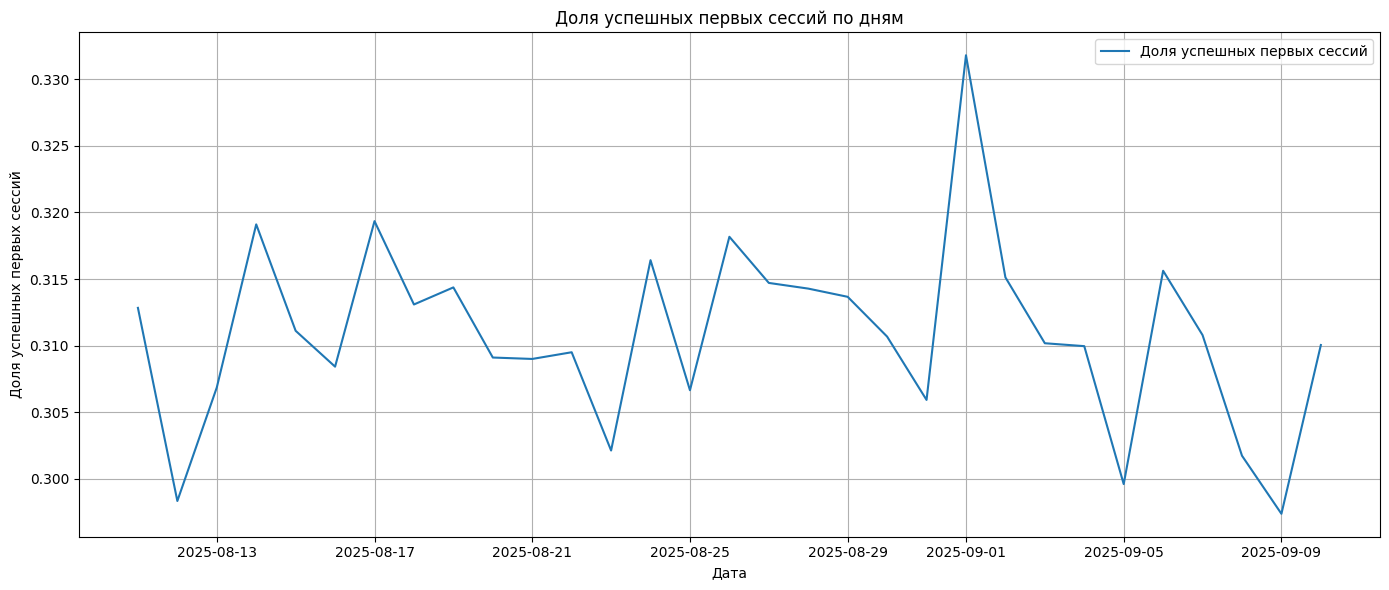

In [36]:
plt.figure(figsize=(14, 6))
plt.plot(daily_good_share['session_date'], daily_good_share['good_session'], label='Доля успешных первых сессий')
plt.title('Доля успешных первых сессий по дням')
plt.xlabel('Дата')
plt.ylabel('Доля успешных первых сессий')
plt.grid(True)
plt.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 2. Подготовка к тесту
При планировании теста необходимо проделать несколько важных шагов:

- Определиться с целевой метрикой.

- Рассчитать необходимый размер выборки.

- Исходя из текущих значений трафика рассчитать необходимую длительность проведения теста.

#### 2.1. Расчёт размера выборки
Параметры:

- Уровень значимости — 0.05.

- Вероятность ошибки второго рода — 0.2.

- Мощность теста.

- Минимальный детектируемый эффект, или MDE, — 3%. Обратите внимание, что здесь нужно указать десятичную дробь, а не процент.

In [37]:
alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода, часто 1 - мощность
power = 0.8  # Мощность теста
p = 0.3 # Базовый уровень конверсии
mde = 0.03  # Увеличение конверсии на 3 п.п.

effect_size = proportion_effectsize(p, p + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Расчёт размера выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1, # Равномерное распределение выборок
    alternative='two-sided'
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 3761


#### 2.2. Расчёт длительности A/B-теста

Используйте данные о количестве пользователей в каждой выборке и среднем количестве пользователей приложения. Рассчитайте длительность теста, разделив одно на другое.

- Рассчитайте среднее количество уникальных пользователей приложения в день.

- Определите длительность теста исходя из рассчитанного значения размера выборок и среднего дневного трафика приложения. Количество дней округлите в большую сторону.

In [38]:
# Среднее количество пользователей приложения в день по историческим данным
avg_daily_users = round(daily_stats['total_users'].mean(),0)

# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
test_duration = ceil(sample_size * 2 / avg_daily_users)

print(f"Рассчитанная длительность A/B-теста при текущем уровене трафика в {avg_daily_users} пользователей в день составит {test_duration} дней")

Рассчитанная длительность A/B-теста при текущем уровене трафика в 9907.0 пользователей в день составит 1 дней


### 3. Мониторинг А/В-теста

#### 3.1. Проверка распределения пользователей

A/B-тест успешно запущен, и уже доступны данные за первые три дня. На этом этапе нужно убедиться, что всё идёт хорошо: пользователи разделены правильным образом, а интересующие вас метрики корректно считаются.

- Считайте и сохраните в датафрейм `sessions_test_part` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test_part.csv`.

- Рассчитайте количество уникальных пользователей в каждой из экспериментальных групп для одного дня наблюдения.

- Рассчитайте и выведите на экран процентную разницу в количестве пользователей в группах A и B. Постройте любую удобную визуализацию, на которой будет видно возможное различие двух групп.

Для расчёта процентной разницы воспользуйтесь формулой:
$$P = 100 \cdot  \frac{|A − B|}{A}$$

In [39]:
sessions_test_part = pd.read_csv('sessions_project_test_part.csv')

sessions_test_part.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group
0,3404844B53442747,B4901323BD537E45,2025-10-14,2025-10-14 19:28:49,2025-10-14,1,0,3,CIS,Android,B
1,3A2BF4D364E62D89,216FC619308F8788,2025-10-14,2025-10-14 21:11:04,2025-10-14,1,0,3,MENA,iPhone,A
2,79CDAE11E32B1597,EDFCE4AC1A504074,2025-10-14,2025-10-14 21:44:03,2025-10-14,1,0,3,CIS,iPhone,A
3,D6AF8D78297A931F,CF0AC0EEDE92C690,2025-10-14,2025-10-14 19:07:55,2025-10-14,1,0,4,CIS,PC,A
4,37E0CE723AE568E0,2E6ED45E8C86C4E9,2025-10-14,2025-10-14 15:39:44,2025-10-14,1,0,3,CIS,Mac,B


In [40]:
# Считаем количество уникальных пользователей в каждой группе
users_per_group = sessions_test_part.groupby('test_group')['user_id'].nunique()

print(users_per_group)

test_group
A    1477
B    1466
Name: user_id, dtype: int64


In [41]:
users_a = users_per_group['A']
users_b = users_per_group['B']

# Считаем процентную разницу по формуле P = 100 * |A - B| / A
percent_diff = 100 * abs(users_a - users_b) / users_a

print(f"Пользователей в группе A: {users_a}")
print(f"Пользователей в группе B: {users_b}")
print(f"Процентная разница между группами: {percent_diff:.2f}%")

Пользователей в группе A: 1477
Пользователей в группе B: 1466
Процентная разница между группами: 0.74%


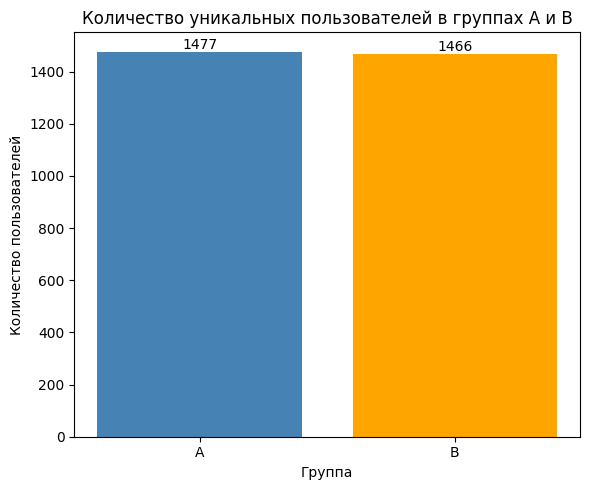

In [42]:
plt.figure(figsize=(6, 5))
bars = plt.bar(users_per_group.index, users_per_group.values, color=['steelblue', 'orange'])
plt.title('Количество уникальных пользователей в группах A и B')
plt.xlabel('Группа')
plt.ylabel('Количество пользователей')
plt.grid(False, axis='y')

# Подписываем значения над столбцами
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'{int(height)}', 
              ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

#### 3.2. Проверка пересечений пользователей
Помимо проверки равенства количества пользователей в группах, полезно убедиться в том, что группы независимы. Для этого нужно убедиться, что никто из пользователей случайно не попал в обе группы одновременно.

- Рассчитайте количество пользователей, которые встречаются одновременно в группах A и B, или убедитесь, что таких нет.

In [43]:
users_a_set = set(sessions_test_part[sessions_test_part['test_group'] == 'A']['user_id'])
users_b_set = set(sessions_test_part[sessions_test_part['test_group'] == 'B']['user_id'])

intersection = users_a_set & users_b_set

print(f"Количество пользователей, попавших в обе группы: {len(intersection)}")

if len(intersection) == 0:
    print("Пересечений не обнаружено — группы независимы.")
else:
    print("Обнаружены пользователи в обеих группах одновременно:")
    print(intersection)

Количество пользователей, попавших в обе группы: 0
Пересечений не обнаружено — группы независимы.


#### 3.3. Равномерность разделения пользователей по устройствам
Полезно также убедиться в том, что пользователи равномерно распределены по всем доступным категориальным переменным — типам устройств и регионам.

Постройте две диаграммы:

- доля каждого типа устройства для пользователей из группы A,

- доля каждого типа устройства для пользователей из группы B.

Постарайтесь добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение устройств в группах A и B.


In [44]:
device_users_a = sessions_test_part[sessions_test_part['test_group'] == 'A'].groupby('device')['user_id'].nunique()
device_users_b = sessions_test_part[sessions_test_part['test_group'] == 'B'].groupby('device')['user_id'].nunique()

device_share_a = round(device_users_a / device_users_a.sum(),2)
device_share_b = round(device_users_b / device_users_b.sum(),2)

print("Доля устройств в группе A (по уникальным пользователям):")
print(device_share_a)
print("\nДоля устройств в группе B (по уникальным пользователям):")
print(device_share_b)

Доля устройств в группе A (по уникальным пользователям):
device
Android    0.44
Mac        0.11
PC         0.25
iPhone     0.20
Name: user_id, dtype: float64

Доля устройств в группе B (по уникальным пользователям):
device
Android    0.46
Mac        0.10
PC         0.26
iPhone     0.18
Name: user_id, dtype: float64


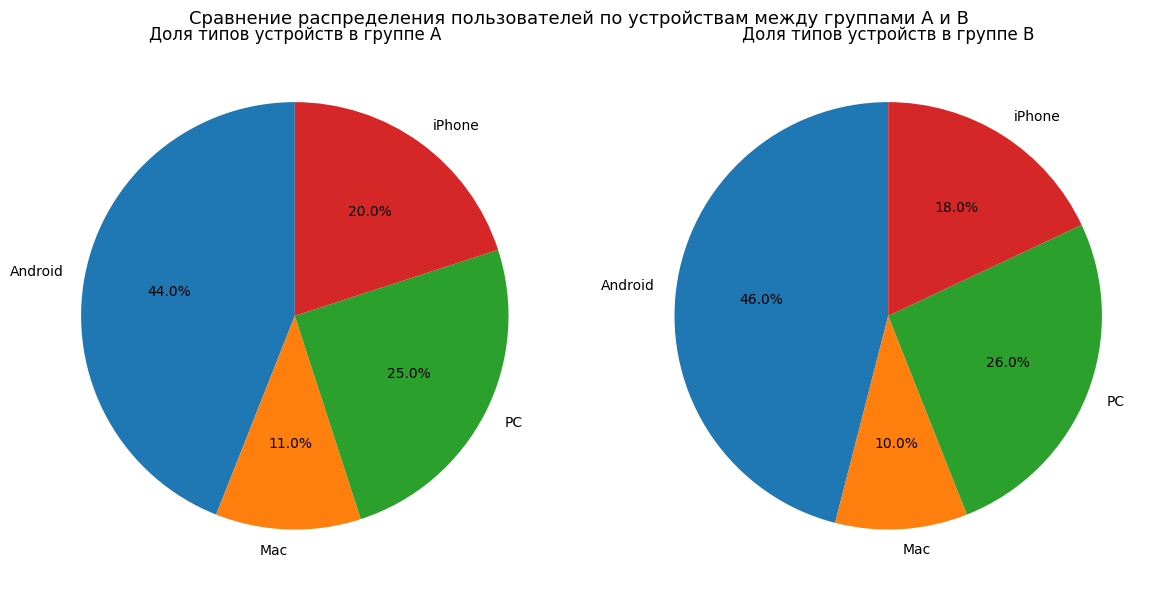

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].pie(device_share_a.values, labels=device_share_a.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Доля типов устройств в группе A')

axes[1].pie(device_share_b.values, labels=device_share_b.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Доля типов устройств в группе B')

fig.suptitle('Сравнение распределения пользователей по устройствам между группами A и B', fontsize=13)
plt.tight_layout()
plt.show()

#### 3.4. Равномерность распределения пользователей по регионам
Теперь убедитесь, что пользователи равномерно распределены по регионам.

Постройте две диаграммы:

- доля каждого региона для пользователей из группы A,

- доля каждого региона для пользователей из группы B.

Постарайтесь добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение регионов в группах A и B. Постарайтесь использовать другой тип диаграммы, не тот, что в прошлом задании.

In [46]:
region_users_a = sessions_test_part[sessions_test_part['test_group'] == 'A'].groupby('region')['user_id'].nunique()
region_users_b = sessions_test_part[sessions_test_part['test_group'] == 'B'].groupby('region')['user_id'].nunique()

region_share_a = round(region_users_a / region_users_a.sum(), 2)
region_share_b = round(region_users_b / region_users_b.sum(), 2)

print("Доля регионов в группе A (по уникальным пользователям):")
print(region_share_a)
print("\nДоля регионов в группе B (по уникальным пользователям):")
print(region_share_b)

Доля регионов в группе A (по уникальным пользователям):
region
CIS     0.44
EU      0.15
MENA    0.41
Name: user_id, dtype: float64

Доля регионов в группе B (по уникальным пользователям):
region
CIS     0.44
EU      0.15
MENA    0.41
Name: user_id, dtype: float64


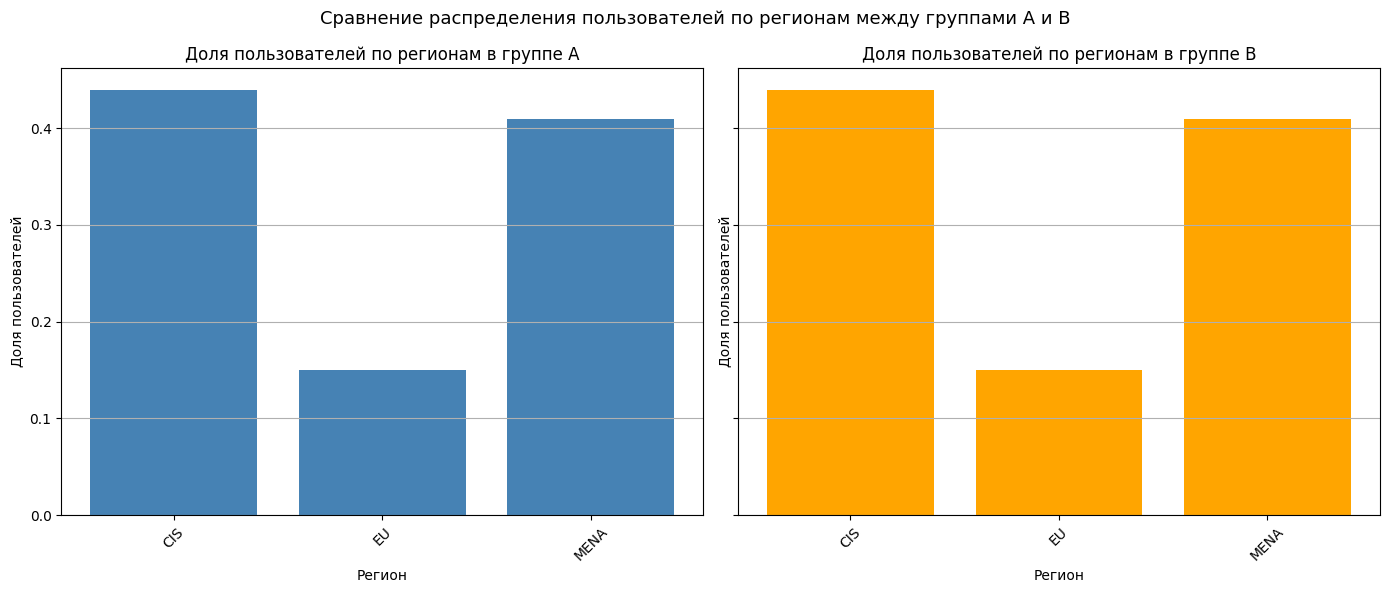

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

axes[0].bar(region_share_a.index, region_share_a.values, color='steelblue')
axes[0].set_title('Доля пользователей по регионам в группе A')
axes[0].set_xlabel('Регион')
axes[0].set_ylabel('Доля пользователей')
axes[0].grid(True, axis='y')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(region_share_b.index, region_share_b.values, color='orange')
axes[1].set_title('Доля пользователей по регионам в группе B')
axes[1].set_xlabel('Регион')
axes[1].set_ylabel('Доля пользователей')
axes[1].grid(True, axis='y')
axes[1].tick_params(axis='x', rotation=45)

fig.suptitle('Сравнение распределения пользователей по регионам между группами A и B', fontsize=13)
plt.tight_layout()
plt.show()

#### 3.5. Вывод после проверки A/B-теста

На основе проведённого анализа A/B-теста сформулируйте и запишите свои выводы. В выводе обязательно укажите:

- Было ли обнаружено различие в количестве пользователей в двух группах.

- Являются ли выборки независимыми. Было ли обнаружено пересечение пользователей из тестовой и контрольной групп.

- Сохраняется ли равномерное распределение пользователей тестовой и контрольной групп по категориальным переменным: устройствам и регионам.

Сделайте заключение: корректно ли проходит A/B-тест, или наблюдаются какие-либо нарушения.

**Выводы после проверки A/B-теста:**
Проверка первого дня A/B-теста (1477 пользователей в группе A, 1466 в группе B) показала, что тест в целом настроен корректно:

• Размер групп различается всего на 0.74% — несущественное отклонение.<br> 
• Пересечений пользователей между группами A и B не обнаружено — выборки независимы.<br> 
• Распределение по устройствам практически идентично: Android 44%/46%, PC 25%/26%, iPhone 20%/18%, Mac 11%/10%.<br> 
• Распределение по регионам идентично: CIS 44%/44%, MENA 41%/41%, EU 15%/15%.

### 4. Проверка результатов A/B-теста

A/B-тест завершён, и у вас есть результаты за все дни проведения эксперимента. Необходимо убедиться в корректности теста и верно интерпретировать результаты.

#### 4.1. Получение результатов теста и подсчёт основной метрики

- Считайте и сохраните в датафрейм `sessions_test` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test.csv`.

- В датафрейме `sessions_test` создайте дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если просмотрено меньше.

In [48]:
sessions_test = pd.read_csv('sessions_project_test.csv')

sessions_test['good_session'] = (sessions_test['page_counter'] >= 4).astype(int)

sessions_test.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group,good_session
0,6DAE3B3654DA738E,C69249E26E58F6E2,2025-10-26,2025-10-26 18:15:05,2025-10-16,3,0,3,MENA,Android,A,0
1,0A3FE5D1DD59110A,66D66D7C9F5181B7,2025-10-21,2025-10-21 17:04:53,2025-10-15,2,1,2,CIS,Android,B,0
2,2041F1D7AA740B88,50DE51D42215E74C,2025-10-23,2025-10-23 17:39:29,2025-10-19,3,0,2,MENA,Android,A,0
3,43D7585009168086,5763C0C353C22263,2025-10-24,2025-10-24 15:01:57,2025-10-18,4,0,1,CIS,iPhone,B,0
4,15AD68B14D62D88C,B1AD09F93C1053BC,2025-10-17,2025-10-17 17:34:39,2025-10-17,1,0,2,MENA,Android,B,0


#### 4.2 Формулировка нулевой и альтернативной гипотез. Определение целевой, прокси- и барьерных метрик


Перед тем как проводить А/B-тест, необходимо сформулировать нулевую и альтернативную гипотезы. Напомним изначальное условие: команда разработчиков рекомендательных систем создала новый алгоритм, который, по их мнению, будет показывать более интересный контент для каждого пользователя.

Подумайте, о какой метрике идёт речь и как она будет учтена в формулировке гипотез. Сформулируйте нулевую и альтернативную гипотезы.

Не забывайте, что до проведения эксперимента важно выделять и отслеживать изменение прокси- и барьерных метрик. В имеющихся у вас данных о проведении эксперимента этих метрик нет. Подумайте, какие показатели вы бы выбрали в качестве прокси- и барьерных метрик, если бы проводили этот эксперимент самостоятельно.

**Нулевая и альтернативная гипотезы:**

H₀: доля успешных первых сессий в группе с новым алгоритмом рекомендаций (тест) равна доле в группе со старым алгоритмом (контроль). Новый алгоритм не влияет на метрику.

H₁: доля успешных первых сессий в тестовой группе отличается от контрольной.

**Целевая метрика:** доля успешных первых сессий (good_session), в которых пользователь просмотрел 4 и более страниц. Эта метрика напрямую отражает вовлечённость в контент, что соответствует гипотезе о более интересных рекомендациях

**Прокси‑метрики (косвенные показатели успеха)**:

• среднее число просмотренных страниц за сессию;

• средняя длительность сессии;

• конверсия в регистрацию после первой сессии.

**Барьерные метрики:**

• доля показов рекламы или выручка с рекламы на пользователя. Если алгоритм меняет выдачу так, что реклама показывается реже или менее эффективно, это плохо скажется на монетизации.

• конверсия в платную подписку. Рост вовлечённости не должен снижать желание платить за отсутствие рекламы.

• технические метрики: время загрузки ленты, доля сессий с ошибками и зависаниями. Новый алгоритм не должен ухудшать пользовательский опыти и технические показатели приложения.

#### 4.3. Сравнение доли успешных первых сессий

Перейдем к анализу ключевой метрики — доле успешных первых сессий.

Используйте созданный на первом шаге задания столбец `good_session` и рассчитайте долю успешных первых сессий для выборок A и B, а также разницу в этом показателе. Полученный вывод отобразите на экране.

In [49]:
# Оставляем только первые сессии пользователей
first_sessions_test = sessions_test[sessions_test['session_number'] == 1]

# Считаем долю успешных первых сессий для групп A и B
good_share_a = first_sessions_test[first_sessions_test['test_group'] == 'A']['good_session'].mean()
good_share_b = first_sessions_test[first_sessions_test['test_group'] == 'B']['good_session'].mean()

diff = good_share_b - good_share_a

print(f"Доля успешных первых сессий в группе A: {good_share_a:.4f}")
print(f"Доля успешных первых сессий в группе B: {good_share_b:.4f}")
print(f"Разница (B - A): {diff:.4f}")
print(f"Разница в процентных пунктах: {diff * 100:.2f} п.п.")
print(f"Относительный прирост: {diff / good_share_a * 100:.2f}%")

Доля успешных первых сессий в группе A: 0.3157
Доля успешных первых сессий в группе B: 0.3147
Разница (B - A): -0.0011
Разница в процентных пунктах: -0.11 п.п.
Относительный прирост: -0.33%


#### 4.4. Насколько статистически значимо изменение ключевой метрики

На предыдущем шаге вы убедились, что доли успешных первых сессий в тестовой и контрольной выборках близки, но делать выводы только на основе этого значения будет некорректно. Для принятия решения всегда необходимо отвечать на вопрос: является ли это изменение статистически значимым.

- Используя статистический тест, рассчитайте, является ли изменение в метрике доли успешных первых сессий статистически значимым.

- Выведите на экран полученное значение p-value и свои выводы о статистической значимости. Напомним, что уровень значимости в эксперименте был выбран на уровне 0.05.

In [50]:
# Количество успешных сессий и общее число сессий в каждой группе
success_A = first_sessions_test[first_sessions_test['test_group'] == 'A']['good_session'].sum()
total_A = len(first_sessions_test[first_sessions_test['test_group'] == 'A'])

success_B = first_sessions_test[first_sessions_test['test_group'] == 'B']['good_session'].sum()
total_B = len(first_sessions_test[first_sessions_test['test_group'] == 'B'])

# двусторонний Z‑тест
stat, p_value = proportions_ztest(
    count=[success_A, success_B],
    nobs=[total_A, total_B],
    alternative='two-sided'
)

print(f"P‑value: {p_value:.4f}")
if p_value < alpha:
    print("Различие статистически значимо. Отклоняем H0.")
else:
    print("Различие не статистически значимо. Не отклоняем H0.")
print(total_A, total_B)

P‑value: 0.8433
Различие не статистически значимо. Не отклоняем H0.
15162 15416


#### 4.5. Вывод по результатам A/B-эксперимента

На основе проведённого анализа результатов теста сформулируйте и запишите свои выводы для команды разработки приложения. В выводе обязательно укажите:

- Характеристики проведённого эксперимента, количество задействованных пользователей и длительность эксперимента.

- Повлияло ли внедрение нового алгоритма рекомендаций на рост ключевой метрики и как.

- Каким получилось значение p-value для оценки статистической значимости выявленного эффекта.

- Стоит ли внедрять нововведение в приложение.

**Вывод по результатам A/B-эксперимента:**


**Характеристики эксперимента**

Тест проводился 20 дней с 2025-10-14 по 2025-11-02. Для обнаружения относительного эффекта в 3% (абсолютный MDE ≈ 0.9 п.п. при базовой доле 30%) с мощностью 80% и уровнем значимости 0.05 требовалось 41 040 пользователей в каждой группе. Фактически в эксперименте участвовало 15 162 пользователя в группе A и 15 416 пользователей в группе B (всего 30 578 чел.). Тест не до конца набрал заложенной статичестической мощности, это стоит учитывать при интерпретации результата.

**Влияние нового алгоритма на ключевую метрику**

Доля успешных первых сессий (просмотр 4+ страниц) составила:

• группа A (контроль): 31.57% <br>
• группа B (тест): 31.47%

Разница = −0.11 п.п. (−0.33% в относительном выражении). Направление эффекта отрицательное, но на уровне статистического шума.

**Статистическая значимость**

Z-тест для сравнения долей дал p-value = 0.8433, что превышает уровень значимости 0.05. Нулевая гипотеза не отклоняется: различие между группами статистически не значимо.

**Итоговая рекомендация по внедрению нового алгоритма**

Внедрять новый алгоритм рекомендаций **не стоит**, т.к. эксперимент не подтвердил гипотезу об улучшении вовлечённости: разница между группами практически нулевая, статистически не значима.

При этом стоит отметить ограничение эксперимента: фактический размер выборки (~15 тыс. на группу) заметно меньше расчётного (41 040 на группу), то есть тест был статистически недостаточно мощным для гипотезы, заложенной на этапе планирования. Прежде чем окончательно закрывать вопрос о новом алгоритме, стоит:

• либо продлить тест до достижения расчётного размера выборки, чтобы быть уверенными в отсутствии эффекта именно того масштаба (3%), на который рассчитывался тест;

• либо параллельно посмотреть на прокси- и барьерные метрики (retention, показатели монетизации), не входившие в датасет. Возможно, алгоритм влияет на пользователей иначе, чем предполагалось изначально.